In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [15]:
Forest2020 = pd.read_csv("Forest_Area_2020_by_District.csv")
Forest2025 = pd.read_csv("Forest_Area_2025_By_District(1).csv")
UrbanChange = pd.read_csv("Urban_expansion_2020_and_2025(2).csv")
ForestComparison = pd.merge(Forest2020, Forest2025,on='ADM2_NAME', how='inner', suffixes=('_2020', '_2025'))
UrbanForestComparison = pd.merge(ForestComparison, UrbanChange, on='ADM2_NAME', how='inner')
print(Forest2020)
print(Forest2025)
print(ForestComparison)
print(UrbanForestComparison)

             ADM2_NAME         sum
0  Gautam Buddha Nagar   96.582177
1                Delhi  322.782154
2              Gurgaon  205.336209
3            Faridabad  191.972379
4            Ghaziabad  598.013961
             ADM2_NAME         sum
0  Gautam Buddha Nagar  178.723679
1                Delhi  389.812515
2              Gurgaon  331.797636
3            Faridabad  300.190866
4            Ghaziabad  725.559033
             ADM2_NAME    sum_2020    sum_2025
0  Gautam Buddha Nagar   96.582177  178.723679
1                Delhi  322.782154  389.812515
2              Gurgaon  205.336209  331.797636
3            Faridabad  191.972379  300.190866
4            Ghaziabad  598.013961  725.559033
             ADM2_NAME    sum_2020    sum_2025        sum
0  Gautam Buddha Nagar   96.582177  178.723679   4.217476
1                Delhi  322.782154  389.812515   5.942030
2              Gurgaon  205.336209  331.797636  10.120745
3            Faridabad  191.972379  300.190866   5.319172
4       

In [20]:
UrbanForestComparison = UrbanForestComparison.rename(columns={'ADM2_NAME':'District','sum_2020':'Forest_km2_2020','sum_2025':'Forest_km2_2025','sum':'Urban_expansion_km2'})
UrbanForestComparison["Growth_km2"] = UrbanForestComparison["Forest_km2_2025"] - UrbanForestComparison["Forest_km2_2020"]
UrbanForestComparison["Growth_Percentage"] = (UrbanForestComparison["Growth_km2"] / UrbanForestComparison["Forest_km2_2020"]) * 100
UrbanForestComparison = UrbanForestComparison.sort_values(by="Urban_expansion_km2", ascending=False)
print(UrbanForestComparison)

              District  Forest_km2_2020  Forest_km2_2025  Urban_expansion_km2  \
2              Gurgaon       205.336209       331.797636            10.120745   
4            Ghaziabad       598.013961       725.559033             6.417386   
1                Delhi       322.782154       389.812515             5.942030   
3            Faridabad       191.972379       300.190866             5.319172   
0  Gautam Buddha Nagar        96.582177       178.723679             4.217476   

   Growth_km2  Growth_Percentage  
2  126.461427          61.587495  
4  127.545072          21.328109  
1   67.030361          20.766439  
3  108.218486          56.371905  
0   82.141502          85.048303  


In [17]:
ForestComparison.to_csv("district_growth.csv", index=False)

[Text(0, 0, '85.0483'),
 Text(0, 0, '61.5875'),
 Text(0, 0, '56.3719'),
 Text(0, 0, '21.3281'),
 Text(0, 0, '20.7664')]

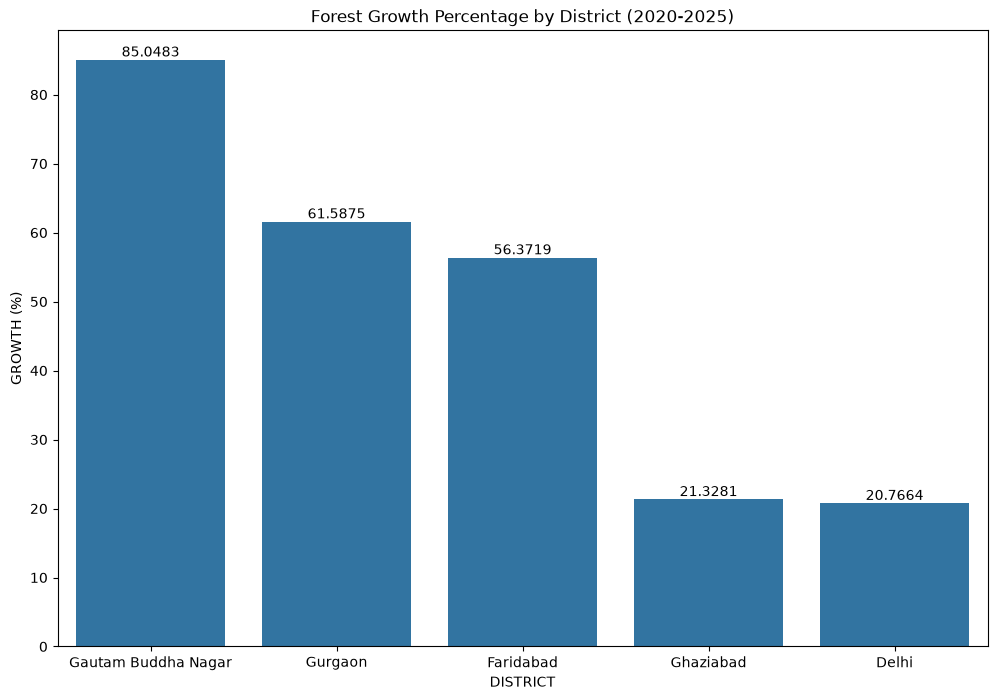

In [19]:
plt.figure(figsize=(12, 8))
plt.title('Forest Growth Percentage by District (2020-2025)')
plt.xlabel('DISTRICT')
plt.ylabel('GROWTH (%)')
ax = sns.barplot(x='District', y='Growth_Percentage', data=UrbanForestComparison)
ax.bar_label(ax.containers[0])
# plt.bar_label(plt.bar(ForestComparison['District'], ForestComparison['Growth_Percentage']), fmt='%.2f%%')

the original task asked for forest loss , but the numbers turned out to be exactly opposite therefore it is about the forest growth

<Axes: xlabel='Urban_expansion_km2', ylabel='Growth_Percentage'>

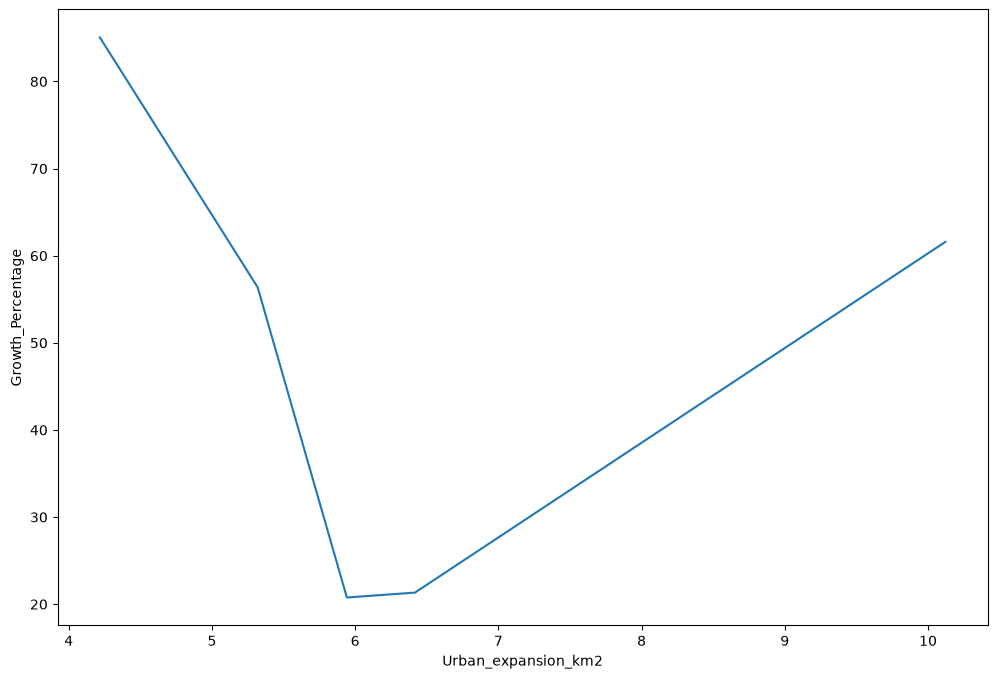

In [21]:
plt.figure(figsize=(12, 8))
sns.lineplot(x='Urban_expansion_km2', y='Growth_Percentage', data=UrbanForestComparison)


No consistent relationship emerges between urban expansion and forest growth across the five districts in this window — the district with the highest urban expansion (Gurgaon) also shows the second-highest forest growth, while the district with the lowest urban expansion (GBN) shows the highest forest growth.

In [ ]:
import rasterio as rio
src = rio.open('Ndvi_changed.tif')
print(src.nodata,src.shape)


None (3611, 4205)


In [ ]:
src.read(1)

array([[ 0.27901575,  0.25855362,  0.22995412, ...,         nan,
         0.10287497,         nan],
       [ 0.31910345,  0.25855362,  0.25855362, ...,         nan,
                nan,         nan],
       [ 0.32843733,  0.29738137,  0.29738137, ...,         nan,
                nan,         nan],
       ...,
       [        nan,  0.12684652,         nan, ...,         nan,
                nan,         nan],
       [ 0.13386783,         nan,         nan, ...,         nan,
                nan, -0.13111924],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(3611, 4205), dtype=float32)

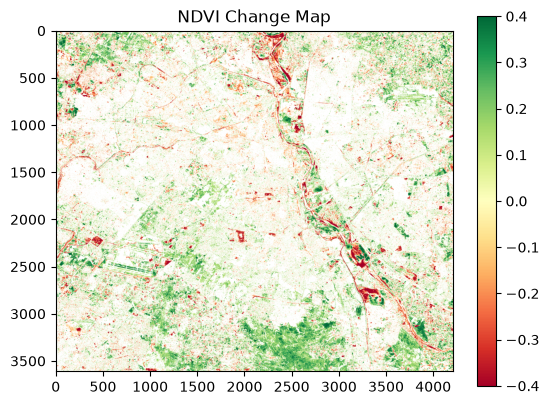

10517768
0 15184255
-1.1906422 1.2227949


In [ ]:
masked_src = np.ma.masked_invalid(src.read(1))
plt.imshow(masked_src , cmap='RdYlGn',vmin=-0.4, vmax=0.4)
plt.colorbar()
plt.title('NDVI Change Map')
plt.show()
print(np.isnan(src.read()).sum())
print(np.isnan(masked_src).sum(),masked_src.size)
print(np.ma.min(masked_src), np.ma.max(masked_src))